In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [ ]:
centroids = gpd.read_file('../../../data/Deployment/UK/FinalPredsCentroids.shp')

In [22]:
centroids

,object_id,area_m2,layer,path,geometry
0,1,1557.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (493770.086 5676820.8)
1,2,156.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (493738.632 5676785.967)
2,3,1762.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (494004.39 5676754.661)
3,4,233.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (495269.16 5675811.816)
4,5,1062.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (493912.346 5675822.686)
...,...,...,...,...,...
3025,569,947.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (471559.352 5617167.383)
3026,570,245.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (472796.239 5617152.421)
3027,571,368.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (475132.725 5617147.699)
3028,572,307.0,Centroids,"Point?crs=EPSG:32630&field=object_id:long(18,0...",POINT (476155.806 5617127.017)


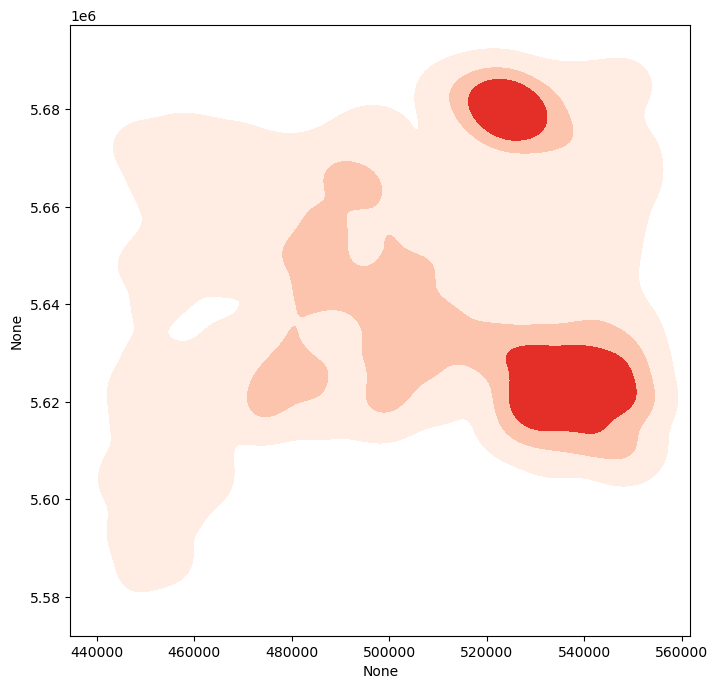

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

x = centroids.geometry.x
y = centroids.geometry.y

fig, ax = plt.subplots(figsize=(8, 8))

sns.kdeplot(
    x=x,
    y=y,
    fill=True,
    cmap="Reds",
    bw_adjust=0.5,
    levels=4,
    thresh=0.01,
    ax=ax
)

ax.set_aspect("equal")
plt.show()

In [ ]:
x = centroids.geometry.x.to_numpy()
y = centroids.geometry.y.to_numpy()

xy = np.vstack([x, y])

kde = gaussian_kde(xy, bw_method=0.1)

xi = np.linspace(x.min(), x.max(), 300)
yi = np.linspace(y.min(), y.max(), 300)
X, Y = np.meshgrid(xi, yi)

Z = kde(
    np.vstack([X.ravel(), Y.ravel()])
).reshape(X.shape)

# Convert KDE probability density -> centroid density
density_per_km2 = Z * len(centroids) * 1_000_000

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    density_per_km2,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="Reds"
)

centroids.plot(
    ax=ax,
    color="black",
    markersize=1,
    alpha=0.2
)

plt.colorbar(
    im,
    ax=ax,
    label=r"Estimated SCD density (km$^{-2}$)"
)

ax.set_aspect("equal")
plt.show()

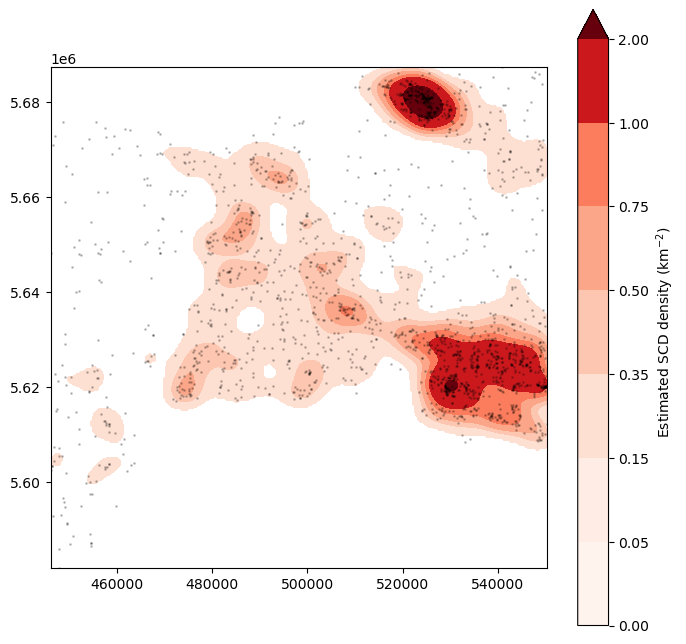

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.colors import BoundaryNorm

x = centroids.geometry.x.to_numpy()
y = centroids.geometry.y.to_numpy()

xy = np.vstack([x, y])

kde = gaussian_kde(xy, bw_method=0.10)

xi = np.linspace(x.min(), x.max(), 300)
yi = np.linspace(y.min(), y.max(), 300)
X, Y = np.meshgrid(xi, yi)

Z = kde(
    np.vstack([X.ravel(), Y.ravel()])
).reshape(X.shape)

# KDE probability density -> estimated centroid density per km²
density_per_km2 = Z * len(centroids) * 1_000_000
density_plot = np.ma.masked_less(density_per_km2, 0.15)

# -------------------------
# DISCRETE DENSITY BINS
# -------------------------



fig, ax = plt.subplots(figsize=(8, 8))

bins = [0, 0.05, 0.15, 0.35, 0.5, 0.75, 1, 2]

cf = ax.contourf(
    X,
    Y,
    density_plot,
    levels=bins,
    cmap="Reds",
    extend="max"
)

centroids.plot(
    ax=ax,
    color="black",
    markersize=1,
    alpha=0.2
)

plt.colorbar(
    cf,
    ax=ax,
    label=r"Estimated SCD density (km$^{-2}$)"
)

plt.show()

In [20]:
print(np.nanpercentile(
    density_per_km2,
    [0, 25, 50, 75, 90, 95, 99, 100]
))

[1.49729373e-52 2.51317195e-03 7.04143442e-02 1.93615630e-01
 4.04671752e-01 7.39728449e-01 1.61308660e+00 3.21059723e+00]


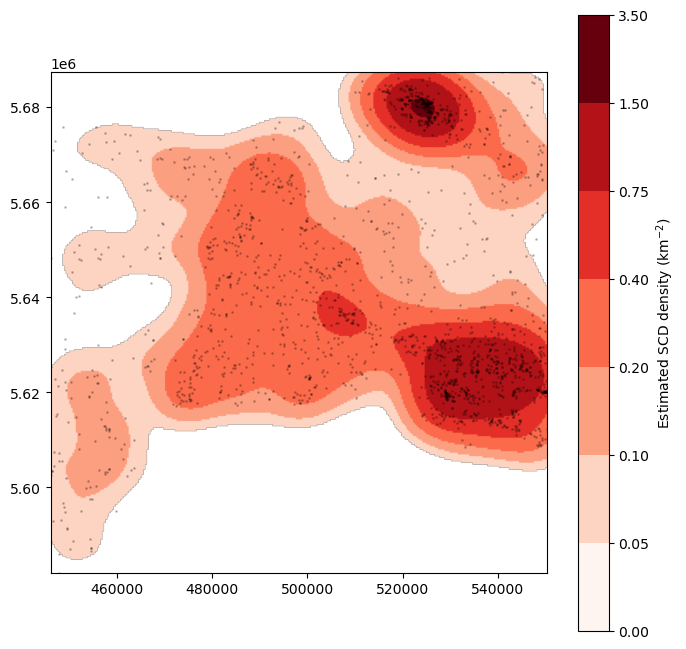

In [62]:
from matplotlib.colors import BoundaryNorm

bins = [0, 0.05, 0.1, 0.2, 0.4, 0.75, 1.5, 3.5]
density_plot = np.ma.masked_less(density_per_km2, 0.05)
cmap = plt.get_cmap("Reds", len(bins) - 1)
norm = BoundaryNorm(bins, cmap.N)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    density_plot,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=cmap,
    norm=norm
)

centroids.plot(
    ax=ax,
    color="black",
    markersize=1,
    alpha=0.2
)

cbar = plt.colorbar(
    im,
    ax=ax,
    boundaries=bins,
    ticks=bins,
    label=r"Estimated SCD density (km$^{-2}$)"
)

ax.set_aspect("equal")
plt.show()